IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df=pd.read_csv('spam.csv', encoding="latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
df.shape

(5572, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

DATA CLEANING

In [8]:
df.dropna(axis=1,inplace=True)

In [9]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [15]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
lb=LabelEncoder()

In [18]:
df['target']=lb.fit_transform(df['target'])

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(5169, 2)

EDA

In [23]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [25]:
(df['target'].value_counts()/len(df['target']))*100

target
0    87.366996
1    12.633004
Name: count, dtype: float64

<Axes: xlabel='target', ylabel='count'>

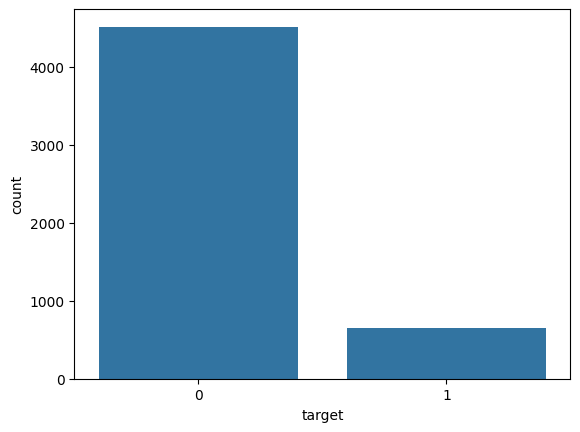

In [26]:
sns.countplot(data=df,x='target')

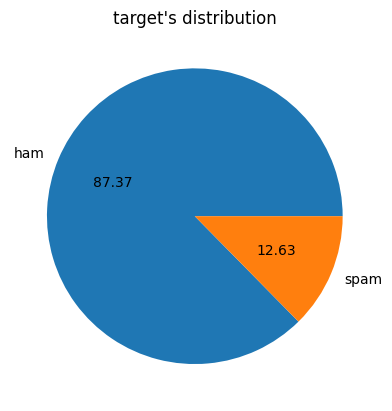

In [27]:
plt.pie(x=df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.title("target's distribution")
plt.show()

In [28]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [29]:
s='jfnj ncdfmnck,ndrjknvl jndxk'
len(s)

28

In [30]:
df['num_char']=df['text'].apply(lambda x:len(x))

In [31]:
!pip install nltk

In [32]:
import nltk

In [33]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Priya
[nltk_data]     Gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Priya
[nltk_data]     Gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [34]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [35]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [36]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [37]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [38]:
df.groupby('target').mean(numeric_only=True)

,num_char,num_words,num_sentences
target,,,
0,70.459256,17.123782,1.820195
1,137.891271,27.667688,2.970904


In [39]:
df.describe()[['num_char','num_words','num_sentences']]

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [40]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


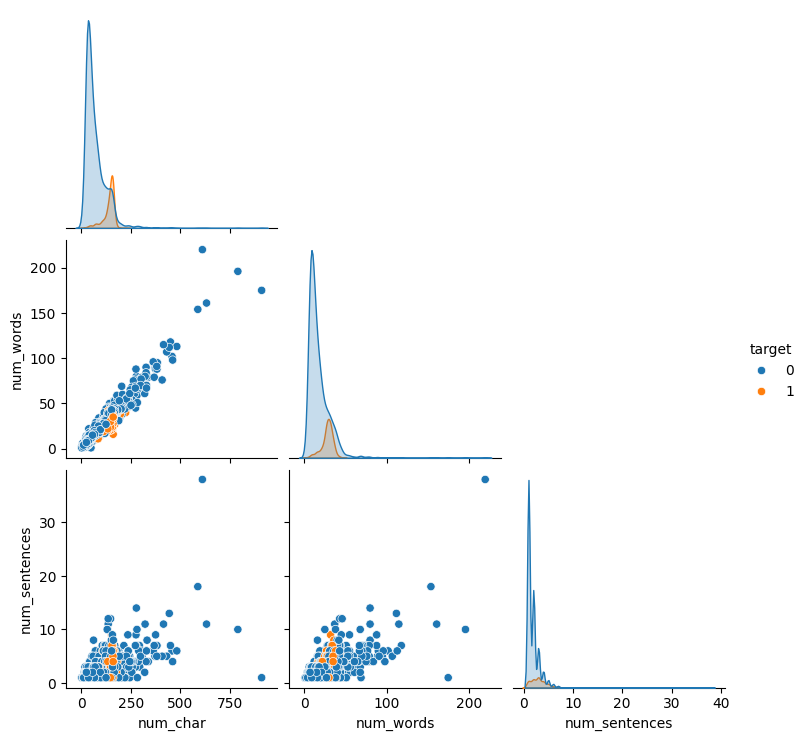

In [41]:
sns.pairplot(df,hue='target',corner=True)

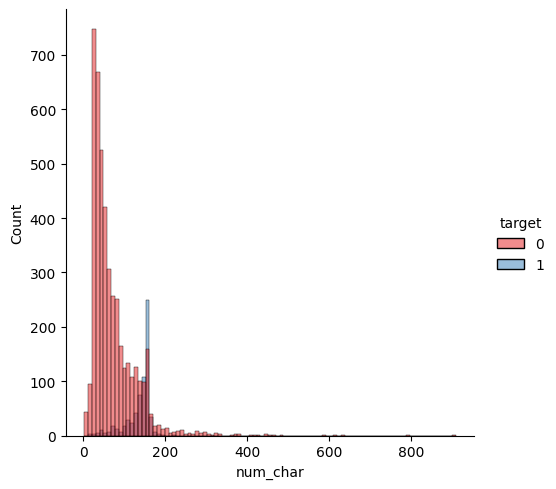

In [42]:
sns.displot(data=df,x='num_char',hue='target',palette='Set1')

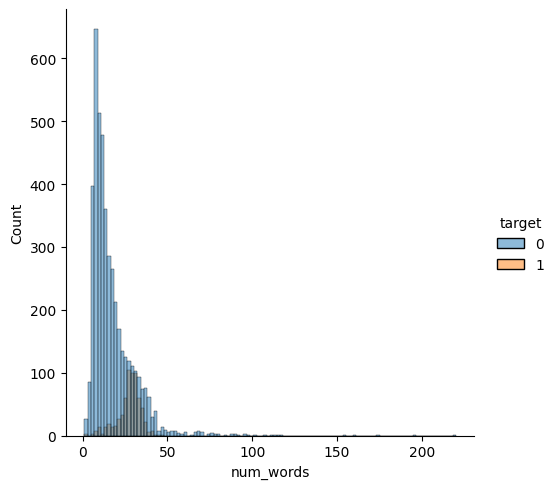

In [43]:
sns.displot(data=df,x='num_words',hue='target')

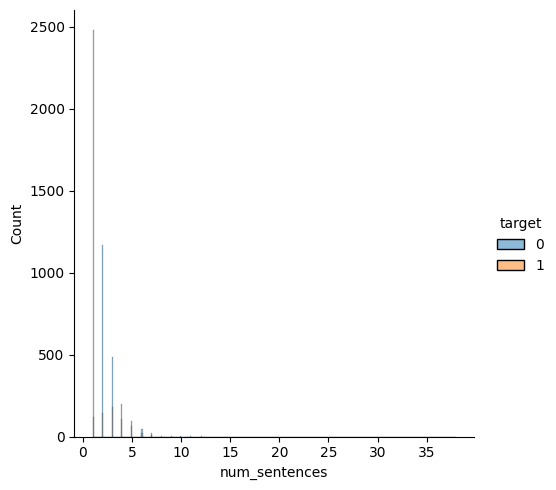

In [44]:
sns.displot(data=df,x='num_sentences',hue='target')

In [45]:
df.corr(numeric_only=True)

,target,num_char,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

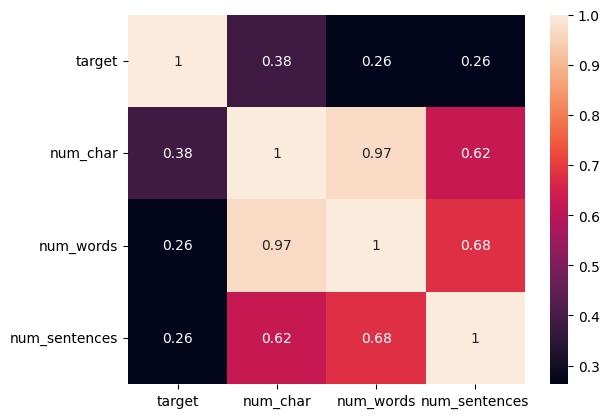

In [46]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#here we can observe high multicollinearity(num_char highly correlated with num_words and num_char correlated with num_sentences)
#makes sense to keep only 1 input
#we'll choose num_char as its influencing the target most

TEXT PREPROCESSING

In [47]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [48]:
def clean_text(text):
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.stem import PorterStemmer
    from nltk.corpus import stopwords
    import string

    #lower case
    text=text.lower()
    #tokenising
    text=word_tokenize(text)
    #remove special chars
    text=[i for i in text if i.isalnum()==True]
    #remove stopwords
    stopwords=stopwords.words('english')
    text=[i for i in text if i not in stopwords]
    #remove punctuations
    p=string.punctuation
    text=[i for i in text if i not in p]
    #stemming
    ps=PorterStemmer()
    #text=[ps.stem(i) for i in text]
    return " ".join(text)

In [49]:
df['transformed_text']=df['text'].apply(clean_text)

In [50]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though


In [51]:
#word cloud to visualise which words occur more in spam text

In [52]:
!pip install wordcloud

In [53]:
from wordcloud import WordCloud

In [54]:
wc=WordCloud()

In [55]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

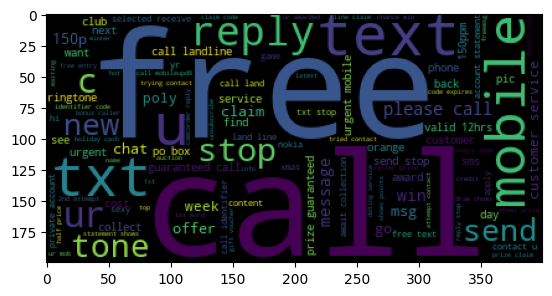

In [56]:
plt.imshow(spam_wc)

In [57]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

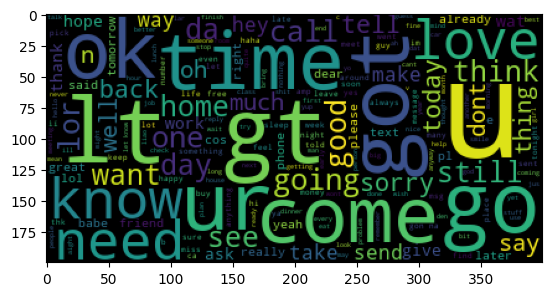

In [58]:
plt.imshow(ham_wc)

In [59]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [60]:
len(spam_corpus)

9939

In [61]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 302),
 ('free', 191),
 ('2', 155),
 ('txt', 130),
 ('u', 119),
 ('ur', 119),
 ('mobile', 105),
 ('text', 104),
 ('stop', 104),
 ('4', 97),
 ('claim', 96),
 ('reply', 96),
 ('prize', 81),
 ('get', 70),
 ('new', 64),
 ('send', 58),
 ('urgent', 57),
 ('nokia', 54),
 ('cash', 51),
 ('contact', 51),
 ('please', 49),
 ('service', 48),
 ('win', 47),
 ('c', 45),
 ('phone', 43),
 ('guaranteed', 42),
 ('per', 41),
 ('week', 40),
 ('customer', 40),
 ('tone', 38)]

MODEL BUILDING AND EVALUATION

In [62]:
#Text Vectorization using TFIDF

In [63]:
df.shape

(5169, 6)

In [64]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though


In [65]:
!pip install imbalanced-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV,GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import precision_recall_curve,precision_score,recall_score,auc,f1_score

In [66]:
x=df['transformed_text'].values
y=df['target'].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42)

In [67]:
tfidf = TfidfVectorizer()

In [68]:
#logistic regression

In [69]:
pipeline_lr=ImbPipeline([('tfidf',tfidf),('smote',"passthrough"),('lr',LogisticRegression(max_iter=5000))])

In [70]:
params_lr={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],'smote':[SMOTE(),'passthrough'],
           'lr__penalty':['l1','l2'],'lr__class_weight':[None,'balanced'],'lr__C':[0.01,0.1,1,10],'lr__solver':['lbfgs', 'liblinear', 'newton-cg', 'saga']}

In [71]:
cv=StratifiedKFold(n_splits=10, shuffle=True)

In [72]:
rs_lr=RandomizedSearchCV(estimator=pipeline_lr,param_distributions=params_lr,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)

In [73]:
rs_lr.fit(x_train,y_train)

C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
110 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\pipeline.py", line 522, in fit
  

,estimator,Pipeline(step..._iter=5000))])
,param_distributions,"{'lr__C': [0.01, 0.1, ...], 'lr__class_weight': [None, 'balanced'], 'lr__penalty': ['l1', 'l2'], 'lr__solver': ['lbfgs', 'liblinear', ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [74]:
rs_lr.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 3,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.99,
 'smote': 'passthrough',
 'lr__solver': 'liblinear',
 'lr__penalty': 'l2',
 'lr__class_weight': None,
 'lr__C': 10}

In [75]:
rs_lr.best_score_

np.float64(0.9056439987922322)

In [76]:
y_pred_lr=rs_lr.predict(x_test)

In [77]:
prec_lr=precision_score(y_test,y_pred_lr)

In [78]:
rec_lr=recall_score(y_test,y_pred_lr)

In [79]:
f1_lr=f1_score(y_test,y_pred_lr)

In [80]:
#SVC

In [81]:
pipeline_svc=ImbPipeline([('tfidf',tfidf),('smote',"passthrough"),('svc',SVC())])

In [82]:
params_svc={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],'smote':[SMOTE(),'passthrough'],
           'svc__kernel':['linear', 'rbf', 'sigmoid'],'svc__class_weight':[None,'balanced'],'svc__C':[0.01,0.1,1,10],'svc__gamma':['scale', 'auto']}

In [83]:
rs_svc=RandomizedSearchCV(estimator=pipeline_svc,param_distributions=params_svc,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_svc.fit(x_train,y_train )

,estimator,"Pipeline(step...svc', SVC())])"
,param_distributions,"{'smote': [SMOTE(), 'passthrough'], 'svc__C': [0.01, 0.1, ...], 'svc__class_weight': [None, 'balanced'], 'svc__gamma': ['scale', 'auto'], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [84]:
rs_svc.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.99,
 'svc__kernel': 'linear',
 'svc__gamma': 'auto',
 'svc__class_weight': None,
 'svc__C': 1,
 'smote': 'passthrough'}

In [85]:
rs_svc.best_score_

np.float64(0.9178476396059209)

In [86]:
y_pred_svc=rs_svc.predict(x_test)

In [87]:
prec_svc=precision_score(y_test,y_pred_svc)

In [88]:
rec_svc=recall_score(y_test,y_pred_svc)

In [89]:
f1_svc=f1_score(y_test,y_pred_svc)

In [90]:
#Multionomial Naive Bayes

In [91]:
pipeline_nb=ImbPipeline([('tfidf',tfidf),('smote','passthrough'),('nb',MultinomialNB())])

In [92]:
params_nb={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'smote':[SMOTE(),'passthrough'],'nb__alpha':[0.1,0.5,1]}

In [93]:
rs_nb=RandomizedSearchCV(estimator=pipeline_nb,param_distributions=params_nb,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_nb.fit(x_train,y_train)

,estimator,Pipeline(step...inomialNB())])
,param_distributions,"{'nb__alpha': [0.1, 0.5, ...], 'smote': [SMOTE(), 'passthrough'], 'tfidf__max_df': [0.9, 0.95, ...], 'tfidf__max_features': [1000, 2000, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [94]:
rs_nb.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 2,
 'tfidf__max_features': 3000,
 'tfidf__max_df': 0.99,
 'smote': 'passthrough',
 'nb__alpha': 0.1}

In [95]:
rs_nb.best_score_

np.float64(0.9163732075222795)

In [96]:
y_pred_nb=rs_nb.predict(x_test)

In [97]:
prec_nb=precision_score(y_test,y_pred_nb)

In [98]:
rec_nb=recall_score(y_test,y_pred_nb)

In [99]:
f1_nb=f1_score(y_test,y_pred_nb)

In [100]:
#Random Forest with class weights

In [101]:
pipeline_rf=Pipeline([('tfidf',tfidf),('rf',RandomForestClassifier())])

In [102]:
params_rf={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'rf__max_depth':[100,200,None],'rf__n_estimators':[100,200],'rf__class_weight':[None,'balanced']}

In [103]:
rs_rf=RandomizedSearchCV(estimator=pipeline_rf,param_distributions=params_rf,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_rf.fit(x_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'rf__class_weight': [None, 'balanced'], 'rf__max_depth': [100, 200, ...], 'rf__n_estimators': [100, 200], 'tfidf__max_df': [0.9, 0.95, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [104]:
rs_rf.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.99,
 'rf__n_estimators': 200,
 'rf__max_depth': 200,
 'rf__class_weight': 'balanced'}

In [105]:
rs_rf.best_score_

np.float64(0.8961328667342683)

In [106]:
y_pred_rf=rs_rf.predict(x_test)

In [107]:
prec_rf=precision_score(y_test,y_pred_rf)

In [108]:
rec_rf=recall_score(y_test,y_pred_rf)

In [109]:
f1_rf=f1_score(y_test,y_pred_rf)

In [110]:
#balanced random forest

In [111]:
pipeline_brf=Pipeline([('tfidf',tfidf),('brf',BalancedRandomForestClassifier())])

In [112]:
params_brf={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'brf__max_depth':[100,200,300,None],'brf__n_estimators':[100,200]}

In [113]:
rs_brf=RandomizedSearchCV(estimator=pipeline_brf,param_distributions=params_brf,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_brf.fit(x_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'brf__max_depth': [100, 200, ...], 'brf__n_estimators': [100, 200], 'tfidf__max_df': [0.9, 0.95, ...], 'tfidf__max_features': [1000, 2000, ...], ...}"
,n_iter,40
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [114]:
rs_brf.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 5000,
 'tfidf__max_df': 0.95,
 'brf__n_estimators': 100,
 'brf__max_depth': 200}

In [115]:
rs_brf.best_score_

np.float64(0.9401412193250115)

In [116]:
y_pred_brf=rs_brf.predict(x_test)

In [117]:
prec_brf=precision_score(y_test,y_pred_brf)

In [118]:
rec_brf=recall_score(y_test,y_pred_brf)

In [119]:
f1_brf=f1_score(y_test,y_pred_brf)

In [122]:
model=['logistic reg','SVC','Naive Bayes','Random Forest','Balanced Random Forest']
score=[rs_lr.best_score_,rs_svc.best_score_,rs_nb.best_score_,rs_rf.best_score_,rs_brf.best_score_]
prec=[prec_lr,prec_svc,prec_nb,prec_rf,prec_brf]
rec=[rec_lr,rec_svc,rec_nb,rec_rf,rec_brf]
f1=[f1_lr,f1_svc,f1_nb,f1_rf,f1_brf]
performance=pd.DataFrame({'Model':model,'best_f1_score':score,'precision':prec,'recall':rec,'f1_score':f1})

In [123]:
performance.sort_values('f1_score',ascending=False)

,Model,best_f1_score,precision,recall,f1_score
4,Balanced Random Forest,0.940141,0.943089,0.885496,0.913386
1,SVC,0.917848,0.973684,0.847328,0.906122
3,Random Forest,0.896133,1.000000,0.824427,0.903766
2,Naive Bayes,0.916373,0.956522,0.839695,0.894309
0,logistic reg,0.905644,0.947826,0.832061,0.886179


In [124]:
#adding numerical features to see if results improve above the best model as by randomsearchcv

In [125]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though


In [126]:
rs_lr.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 3,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.99,
 'smote': 'passthrough',
 'lr__solver': 'liblinear',
 'lr__penalty': 'l2',
 'lr__class_weight': None,
 'lr__C': 10}

In [129]:
#Logistic Regression
from sklearn.preprocessing import StandardScaler

X = df[['transformed_text', 'num_char', 'num_words', 'num_sentences']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


tfidf = TfidfVectorizer(
    max_features=rs_lr.best_params_['tfidf__max_features'],
    ngram_range=rs_lr.best_params_['tfidf__ngram_range'],
    min_df=rs_lr.best_params_['tfidf__min_df'], 
    max_df=rs_lr.best_params_['tfidf__max_df']
)

scaler = StandardScaler()

#  PREPARE VERSION A: TEXT ONLY
X_train_text = tfidf.fit_transform(X_train['transformed_text']).toarray()
X_test_text = tfidf.transform(X_test['transformed_text']).toarray()

# PREPARE VERSION B: TEXT + NUMERICAL
# Scale numerical features
X_train_num = scaler.fit_transform(X_train[['num_char', 'num_words', 'num_sentences']])
X_test_num = scaler.transform(X_test[['num_char', 'num_words', 'num_sentences']])

# Combine columns 
X_train_combined = np.hstack((X_train_text, X_train_num))
X_test_combined = np.hstack((X_test_text, X_test_num))

lr = LogisticRegression(
    C=rs_lr.best_params_['lr__C'],
    solver=rs_lr.best_params_['lr__solver'],
    class_weight=rs_lr.best_params_['lr__class_weight'],
    penalty=rs_lr.best_params_['lr__penalty']
)

# MODEL 1: TEXT ONLY
lr.fit(X_train_text, y_train)
y_pred_text_lr = lr.predict(X_test_text)
f_lr = f1_score(y_test, y_pred_text_lr)
prec_lr = precision_score(y_test, y_pred_text_lr)
recall_lr = recall_score(y_test, y_pred_text_lr)

# MODEL 2: TEXT + NUMERICAL FEATURES
lr.fit(X_train_combined, y_train)
y_pred_combined_lr = lr.predict(X_test_combined)
f1_lr = f1_score(y_test, y_pred_combined_lr)
prec1_lr = precision_score(y_test, y_pred_combined_lr)
recall1_lr =recall_score(y_test, y_pred_combined_lr)

print("=== MODEL COMPARISON LOGISTIC REGRESSION ===")
print("Without num_features → F1:", f_lr, "| Precision:", prec_lr, "| Recall:", recall_lr)
print("With num_features   → F1:", f1_lr, "| Precision:", prec1_lr, "| Recall:", recall1_lr)

=== MODEL COMPARISON LOGISTIC REGRESSION ===
Without num_features → F1: 0.8861788617886179 | Precision: 0.9478260869565217 | Recall: 0.8320610687022901
With num_features   → F1: 0.8987854251012146 | Precision: 0.9568965517241379 | Recall: 0.8473282442748091


In [130]:
rs_svc.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.99,
 'svc__kernel': 'linear',
 'svc__gamma': 'auto',
 'svc__class_weight': None,
 'svc__C': 1,
 'smote': 'passthrough'}

In [134]:
#SVC
X = df[['transformed_text', 'num_char', 'num_words', 'num_sentences']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


tfidf = TfidfVectorizer(
    max_features=rs_svc.best_params_['tfidf__max_features'],
    ngram_range=rs_svc.best_params_['tfidf__ngram_range'],
    min_df=rs_svc.best_params_['tfidf__min_df'], 
    max_df=rs_svc.best_params_['tfidf__max_df']
)

scaler = StandardScaler()

#  PREPARE VERSION A: TEXT ONLY
X_train_text = tfidf.fit_transform(X_train['transformed_text']).toarray()
X_test_text = tfidf.transform(X_test['transformed_text']).toarray()

# PREPARE VERSION B: TEXT + NUMERICAL
# Scale numerical features
X_train_num = scaler.fit_transform(X_train[['num_char', 'num_words', 'num_sentences']])
X_test_num = scaler.transform(X_test[['num_char', 'num_words', 'num_sentences']])

# Combine columns 
X_train_combined = np.hstack((X_train_text, X_train_num))
X_test_combined = np.hstack((X_test_text, X_test_num))

# SVC
svc=SVC(kernel=rs_svc.best_params_['svc__kernel'],gamma=rs_svc.best_params_['svc__gamma'],C=rs_svc.best_params_['svc__C'],class_weight=rs_svc.best_params_['svc__class_weight'])

# MODEL 1: TEXT ONLY
svc.fit(X_train_text, y_train)
y_pred_text_svc = svc.predict(X_test_text)
f_svc = f1_score(y_test, y_pred_text_svc)
prec_svc = precision_score(y_test, y_pred_text_svc)
recall_svc = recall_score(y_test, y_pred_text_svc)

# MODEL 2: TEXT + NUMERICAL FEATURES
svc.fit(X_train_combined, y_train)
y_pred_combined_svc = svc.predict(X_test_combined)
f1_svc = f1_score(y_test, y_pred_combined_svc)
prec1_svc = precision_score(y_test, y_pred_combined_svc)
recall1_svc =recall_score(y_test, y_pred_combined_svc)

print("=== MODEL COMPARISON SVC ===")
print("Without num_features → F1:", f_svc, "| Precision:", prec_svc, "| Recall:", recall_svc)
print("With num_features   → F1:", f1_svc, "| Precision:", prec1_svc, "| Recall:", recall1_svc)

=== MODEL COMPARISON SVC ===
Without num_features → F1: 0.9061224489795918 | Precision: 0.9736842105263158 | Recall: 0.8473282442748091
With num_features   → F1: 0.9112903225806451 | Precision: 0.9658119658119658 | Recall: 0.8625954198473282


In [141]:
X_train_text

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [140]:
X_train_combined

array([[ 0.        ,  0.        ,  0.        , ..., -0.37805069,
        -0.40866389,  0.02234388],
       [ 0.        ,  0.        ,  0.        , ..., -0.94084157,
        -0.86679733, -0.65700868],
       [ 0.        ,  0.        ,  0.        , ..., -0.2725274 ,
        -0.17959717,  0.02234388],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.38067081,
         1.88200331,  3.41910668],
       [ 0.        ,  0.        ,  0.        , ...,  0.23750183,
         0.12582512,  0.70169644],
       [ 0.        ,  0.        ,  0.        , ..., -0.29011461,
        -0.33230832,  0.02234388]])

In [135]:
rs_nb.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 2,
 'tfidf__max_features': 3000,
 'tfidf__max_df': 0.99,
 'smote': 'passthrough',
 'nb__alpha': 0.1}

In [145]:
#NB
from sklearn.preprocessing import MinMaxScaler
X = df[['transformed_text', 'num_char', 'num_words', 'num_sentences']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


tfidf = TfidfVectorizer(
    max_features=rs_nb.best_params_['tfidf__max_features'],
    ngram_range=rs_nb.best_params_['tfidf__ngram_range'],
    min_df=rs_nb.best_params_['tfidf__min_df'], 
    max_df=rs_nb.best_params_['tfidf__max_df']
)

scaler = MinMaxScaler()

#  PREPARE VERSION A: TEXT ONLY
X_train_text = tfidf.fit_transform(X_train['transformed_text']).toarray()
X_test_text = tfidf.transform(X_test['transformed_text']).toarray()

# PREPARE VERSION B: TEXT + NUMERICAL
# Scale numerical features
X_train_num = scaler.fit_transform(X_train[['num_char', 'num_words', 'num_sentences']])
X_test_num = scaler.transform(X_test[['num_char', 'num_words', 'num_sentences']])

# Combine columns 
X_train_combined = np.hstack((X_train_text, X_train_num))
X_test_combined = np.hstack((X_test_text, X_test_num))

# Naive Bayes
nb=MultinomialNB(alpha=rs_nb.best_params_['nb__alpha'])

# MODEL 1: TEXT ONLY
nb.fit(X_train_text, y_train)
y_pred_text_nb = nb.predict(X_test_text)
f_nb = f1_score(y_test, y_pred_text_nb)
prec_nb = precision_score(y_test,y_pred_text_nb)
recall_nb = recall_score(y_test,y_pred_text_nb)

# MODEL 2: TEXT + NUMERICAL FEATURES
nb.fit(X_train_combined, y_train)
y_pred_combined_nb = nb.predict(X_test_combined)
f1_nb = f1_score(y_test, y_pred_combined_nb)
prec1_nb = precision_score(y_test, y_pred_combined_nb)
recall1_nb =recall_score(y_test, y_pred_combined_nb)

print("Without num_features → F1:", f_nb, "| Precision:", prec_nb, "| Recall:", recall_nb)
print("With num_features   → F1:", f1_nb, "| Precision:", prec1_nb, "| Recall:", recall1_nb)

Without num_features → F1: 0.8943089430894309 | Precision: 0.9565217391304348 | Recall: 0.8396946564885496
With num_features   → F1: 0.8943089430894309 | Precision: 0.9565217391304348 | Recall: 0.8396946564885496


In [136]:
rs_brf.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 1,
 'tfidf__max_features': 5000,
 'tfidf__max_df': 0.99,
 'brf__n_estimators': 200,
 'brf__max_depth': 300}

In [147]:
#BRF

X = df[['transformed_text', 'num_char', 'num_words', 'num_sentences']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


tfidf = TfidfVectorizer(
    max_features=rs_brf.best_params_['tfidf__max_features'],
    ngram_range=rs_brf.best_params_['tfidf__ngram_range'],
    min_df=rs_brf.best_params_['tfidf__min_df'], 
    max_df=rs_brf.best_params_['tfidf__max_df']
)

scaler = StandardScaler()

#  PREPARE VERSION A: TEXT ONLY
X_train_text = tfidf.fit_transform(X_train['transformed_text']).toarray()
X_test_text = tfidf.transform(X_test['transformed_text']).toarray()

# PREPARE VERSION B: TEXT + NUMERICAL
# Scale numerical features
X_train_num = scaler.fit_transform(X_train[['num_char', 'num_words', 'num_sentences']])
X_test_num = scaler.transform(X_test[['num_char', 'num_words', 'num_sentences']])

# Combine columns 
X_train_combined = np.hstack((X_train_text, X_train_num))
X_test_combined = np.hstack((X_test_text, X_test_num))

brf=BalancedRandomForestClassifier(n_estimators=rs_brf.best_params_['brf__n_estimators'],max_depth=rs_brf.best_params_['brf__max_depth'])

# MODEL 1: TEXT ONLY
brf.fit(X_train_text, y_train)
y_pred_text_brf = brf.predict(X_test_text)
f_brf = f1_score(y_test, y_pred_text_brf)
prec_brf = precision_score(y_test,y_pred_text_brf)
recall_brf = recall_score(y_test,y_pred_text_brf)

# MODEL 2: TEXT + NUMERICAL FEATURES
brf.fit(X_train_combined, y_train)
y_pred_combined_brf = brf.predict(X_test_combined)
f1_brf = f1_score(y_test, y_pred_combined_brf)
prec1_brf = precision_score(y_test, y_pred_combined_brf)
recall1_brf =recall_score(y_test, y_pred_combined_brf)

print("Without num_features → F1:", f_brf, "| Precision:", prec_brf, "| Recall:", recall_brf)
print("With num_features   → F1:", f1_brf, "| Precision:", prec1_brf, "| Recall:", recall1_brf)

Without num_features → F1: 0.9126984126984127 | Precision: 0.9504132231404959 | Recall: 0.8778625954198473
With num_features   → F1: 0.8614232209737828 | Precision: 0.8455882352941176 | Recall: 0.8778625954198473


In [138]:
rs_rf.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 3,
 'tfidf__max_features': 1000,
 'tfidf__max_df': 0.9,
 'rf__n_estimators': 200,
 'rf__max_depth': 100,
 'rf__class_weight': None}

In [148]:
#RF

X = df[['transformed_text', 'num_char', 'num_words', 'num_sentences']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


tfidf = TfidfVectorizer(
    max_features=rs_rf.best_params_['tfidf__max_features'],
    ngram_range=rs_rf.best_params_['tfidf__ngram_range'],
    min_df=rs_rf.best_params_['tfidf__min_df'], 
    max_df=rs_rf.best_params_['tfidf__max_df']
)

scaler = StandardScaler()

#  PREPARE VERSION A: TEXT ONLY
X_train_text = tfidf.fit_transform(X_train['transformed_text']).toarray()
X_test_text = tfidf.transform(X_test['transformed_text']).toarray()

# PREPARE VERSION B: TEXT + NUMERICAL
# Scale numerical features
X_train_num = scaler.fit_transform(X_train[['num_char', 'num_words', 'num_sentences']])
X_test_num = scaler.transform(X_test[['num_char', 'num_words', 'num_sentences']])

# Combine columns 
X_train_combined = np.hstack((X_train_text, X_train_num))
X_test_combined = np.hstack((X_test_text, X_test_num))

rf=RandomForestClassifier(n_estimators=rs_rf.best_params_['rf__n_estimators'],max_depth=rs_rf.best_params_['rf__max_depth'],class_weight=rs_rf.best_params_['rf__class_weight'])

# MODEL 1: TEXT ONLY
rf.fit(X_train_text, y_train)
y_pred_text_rf = rf.predict(X_test_text)
f_rf = f1_score(y_test, y_pred_text_rf)
prec_rf = precision_score(y_test,y_pred_text_rf)
recall_rf = recall_score(y_test,y_pred_text_rf)

# MODEL 2: TEXT + NUMERICAL FEATURES
rf.fit(X_train_combined, y_train)
y_pred_combined_rf = rf.predict(X_test_combined)
f1_rf = f1_score(y_test, y_pred_combined_rf)
prec1_rf = precision_score(y_test, y_pred_combined_rf)
recall1_rf =recall_score(y_test, y_pred_combined_rf)

print("Without num_features → F1:", f_rf, "| Precision:", prec_rf, "| Recall:", recall_rf)
print("With num_features   → F1:", f1_rf, "| Precision:", prec1_rf, "| Recall:", recall1_rf)

Without num_features → F1: 0.8962655601659751 | Precision: 0.9818181818181818 | Recall: 0.8244274809160306
With num_features   → F1: 0.8870967741935484 | Precision: 0.9401709401709402 | Recall: 0.8396946564885496


In [140]:
model=['logistic reg','SVC','Naive Bayes','Random Forest','Balanced Random Forest']
f1_score_without_num=[f_lr,f_svc,f_nb,f_rf,f_brf]
precision_without_num=[prec_lr,prec_svc,prec_nb,prec_rf,prec_brf]
recall_without_num=[recall_lr,recall_svc,recall_nb,recall_rf,recall_brf]
f1_score_with_num=[f1_lr,f1_svc,f1_nb,f1_rf,f1_brf]
precision_with_num=[prec1_lr,prec1_svc,prec1_nb,prec_rf,prec1_brf]
recall_with_num=[recall1_lr,recall1_svc,recall1_nb,recall1_rf,recall1_brf]

perf_1=pd.DataFrame({'Model':model,'f1_score_without_num':f1_score_without_num,'precision_without_num':precision_without_num,'recall_without_num':recall_without_num,
                    'f1_score_with_num':f1_score_with_num,'precision_with_num':precision_with_num,'recall_with_num':recall_with_num})

In [141]:
perf_1.sort_values('f1_score_without_num',ascending=False)

,Model,f1_score_without_num,precision_without_num,recall_without_num,f1_score_with_num,precision_with_num,recall_with_num
4,Balanced Random Forest,0.919540,0.923077,0.916031,0.883019,0.873134,0.893130
3,Random Forest,0.901639,0.973451,0.839695,0.900398,0.973451,0.862595
1,SVC,0.901639,0.973451,0.839695,0.909836,0.982301,0.847328
2,Naive Bayes,0.889796,0.956140,0.832061,0.889796,0.956140,0.832061
0,logistic reg,0.882353,0.981308,0.801527,0.902439,0.965217,0.847328


In [142]:
#adding num feature hardly improving f1 score

In [143]:
#ENSEMBLE MODELS

In [149]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Create Voting Classifier with all best models
voting_clf = VotingClassifier(estimators=[('lr', rs_lr.best_estimator_),('svc', rs_svc.best_estimator_),('nb', rs_nb.best_estimator_),('brf', rs_brf.best_estimator_)])

voting_clf.fit(x_train, y_train)

y_pred_vote=voting_clf.predict(x_test)

f1_score_vote=f1_score(y_test, y_pred_vote)
precision_score_vote=precision_score(y_test, y_pred_vote)
recall_score_vote=recall_score(y_test, y_pred_vote)

# Metrics
print("Final F1:", f1_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall:", recall_score(y_test, y_pred_vote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_vote))

Final F1: 0.8962655601659751
Precision: 0.9818181818181818
Recall: 0.8244274809160306

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.97      1034



In [150]:
#Voting improves the model

In [151]:
from sklearn.ensemble import StackingClassifier

In [152]:
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Create Voting Classifier with all best models
stacking_clf = StackingClassifier(estimators=[('lr', rs_lr.best_estimator_),('svc', rs_svc.best_estimator_),('nb', rs_nb.best_estimator_),('brf', rs_brf.best_estimator_)])

stacking_clf.fit(x_train, y_train)

y_pred_stack=stacking_clf.predict(x_test)

f1_score_stack=f1_score(y_test, y_pred_stack)
precision_score_stack=precision_score(y_test, y_pred_stack)
recall_score_stack=recall_score(y_test, y_pred_stack)

# Metrics
print("Final F1:", f1_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

Final F1: 0.9236947791164659
Precision: 0.9745762711864406
Recall: 0.8778625954198473

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.88      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



Stacking improves the model results